# New Hire Test (Monty Hall Variant)

You just got hired as an ML engineer (somehow) and you’re learning on the job. Your boss is testing your decision-making skills. They know which of 3 model architectures (Transformer, CNN, RNN) will actually work for the production system, but you have no clue. You nervously pick Transformer. Your boss then says "Well, so you knew that RNN definitely won’t work for this use case, eh?" and eliminates it. Then they lean back with a slight smile and say: 
"So... do you want to stick with Transformer or switch to CNN?" 
What is your best option?

**Question:** Should you stay with Transformer or switch to CNN?

## Step 1: Define the hypotheses

- `Transformer` works
- `CNN` works
- `RNN` works

Initially, all three hypotheses are equally likely.

In [1]:
priors = {
    "Transformer": 1/3,
    "CNN": 1/3,
    "RNN": 1/3,
}

priors

{'Transformer': 0.3333333333333333,
 'CNN': 0.3333333333333333,
 'RNN': 0.3333333333333333}

## Step 2: Define the evidence

> **Evidence:** The boss eliminates RNN.

We need to compute the likelihoods:

$P(\text{Boss eliminates RNN} \mid H)$

### Likelihood reasoning

**If Transformer works**
- Boss can eliminate CNN or RNN.
- $P(E\mid \text{Transformer}) = 1/2$

**If CNN works**
- Boss must eliminate RNN.
- $P(E\mid \text{CNN}) = 1$

**If RNN works**
- Boss cannot eliminate RNN.
- $P(E\mid \text{RNN}) = 0$

In [4]:
likelihoods = {
    "Transformer": 0.5,
    "CNN": 1.0,
    "RNN": 0.0,
}

likelihoods

{'Transformer': 0.5, 'CNN': 1.0, 'RNN': 0.0}

## Step 3: Solve using `explain_update()`

In [5]:
from probmodels import explain_update

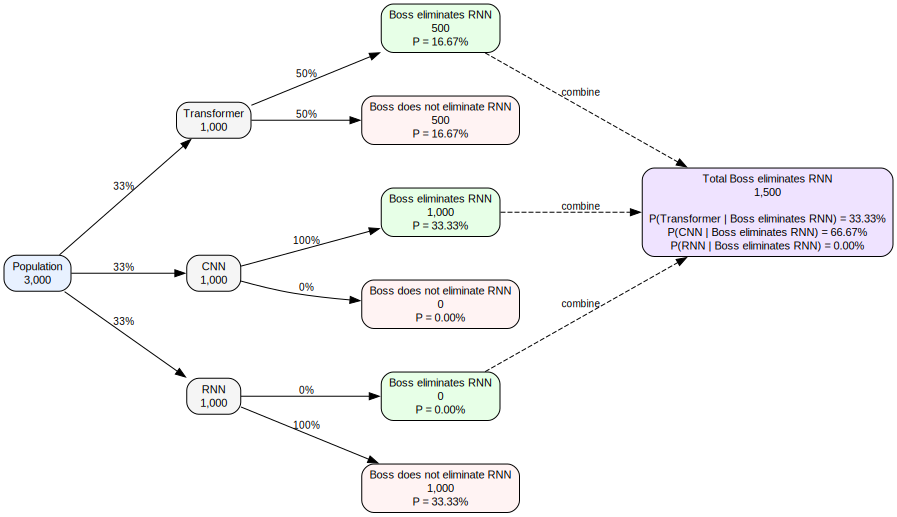

In [6]:
result = explain_update(
    priors=priors,
    likelihoods=likelihoods,
    population_size=3000,
    evidence_name="Boss eliminates RNN",
    no_evidence_name="Boss does not eliminate RNN",
    draw_tree=True,
)

result["tree"]

## Step 4: Posterior Probabilities

After observing that the boss eliminates RNN:

- Transformer: 1/3
- CNN: 2/3
- RNN: 0

**Best decision: Switch to CNN.**

In [7]:
result["posteriors"]

{'Transformer': 0.3333333333333333, 'CNN': 0.6666666666666666, 'RNN': 0.0}

## Key Lesson

The difficult part was not the Bayesian update itself. The difficult part was formulating the likelihoods.

Most Bayesian problems can be solved using:

1. Hypotheses
2. Evidence
3. Priors
4. Likelihoods
5. Bayesian update